In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('data.csv')
df.head(5)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
# Count occurrences of each restaurant name
chain_counts = df['Restaurant Name'].value_counts()

# Filter chains (more than 1 outlet)
chains = chain_counts[chain_counts > 1]

print("Top Restaurant Chains:")
print(chains.head(10))

Top Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [ ]:
# Group by restaurant name and calculate average rating
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

# Merge with count
chain_analysis = pd.DataFrame({
    'Outlet Count': chain_counts,
    'Average Rating': chain_ratings
})

# Filter only chains
chain_analysis = chain_analysis[chain_analysis['Outlet Count'] > 1]

# Sort by rating
top_rated_chains = chain_analysis.sort_values(by='Average Rating', ascending=False)

print("Top Rated Chains:")
print(top_rated_chains.head(10))

Top Rated Chains:
                           Outlet Count  Average Rating
Restaurant Name                                        
Talaga Sampireun                      3           4.900
Silantro Fil-Mex                      2           4.850
AB's Absolute Barbecues               2           4.850
AB's - Absolute Barbecues             4           4.825
Naturals Ice Cream                    2           4.800
Gymkhana                              2           4.700
The Cheesecake Factory                2           4.650
Garota de Ipanema                     2           4.600
Dishoom                               2           4.600
Chili's                               5           4.580


In [ ]:
# Sort by outlet count
most_popular_chains = chain_analysis.sort_values(by='Outlet Count', ascending=False)

print("Most Popular Chains (by number of outlets):")
print(most_popular_chains.head(10))

Most Popular Chains (by number of outlets):
                  Outlet Count  Average Rating
Restaurant Name                               
Cafe Coffee Day             83        2.419277
Domino's Pizza              79        2.740506
Subway                      63        2.907937
Green Chick Chop            51        2.672549
McDonald's                  48        3.339583
Keventers                   34        2.870588
Pizza Hut                   30        3.320000
Giani                       29        2.689655
Baskin Robbins              28        1.860714
Barbeque Nation             26        4.353846


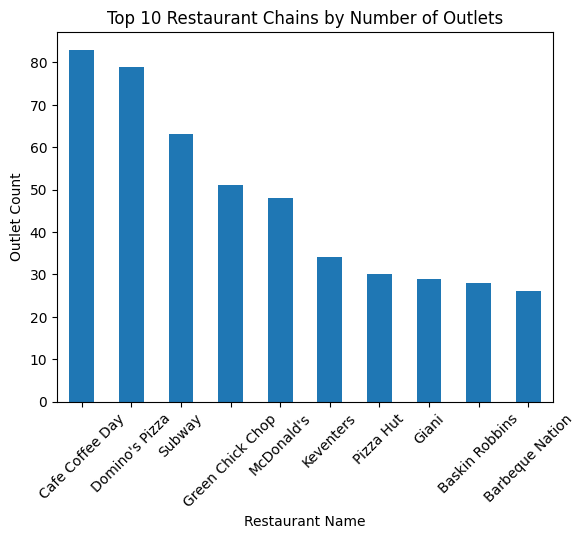

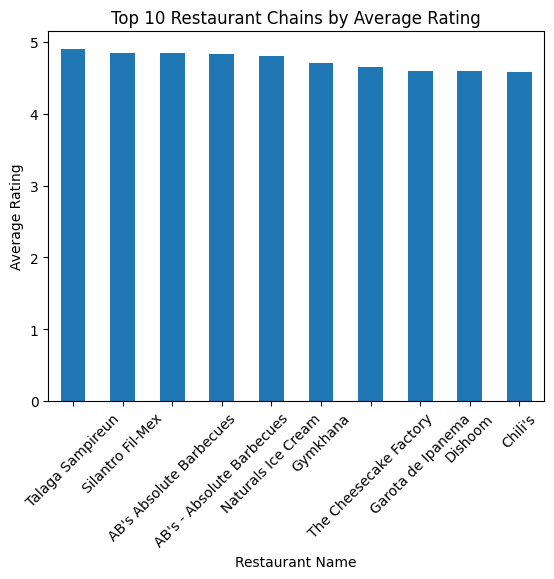

In [ ]:
# Top 10 popular chains
top10 = most_popular_chains.head(10)

plt.figure()
top10['Outlet Count'].plot(kind='bar')
plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.xlabel("Restaurant Name")
plt.ylabel("Outlet Count")
plt.xticks(rotation=45)
plt.show()

# Top 10 rated chains
top10_rating = top_rated_chains.head(10)

plt.figure()
top10_rating['Average Rating'].plot(kind='bar')
plt.title("Top 10 Restaurant Chains by Average Rating")
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()
